# Lab 3 – Linear Regression and Overfitting Analysis

**Name:** Jiya Elza Jabi
**Course:** MCA
**Subject:** Machine Learning Lab

**Aim:** To select a dataset with both numeric and nominal features, perform preprocessing (missing value handling, encoding, scaling), build a Linear Regression model, evaluate it using MAE/MSE/RMSE/R2, and analyze overfitting by comparing training vs testing performance.

**Dataset used:** BigMart Sales dataset (Kaggle) - `Train.csv`. Picked this one because it has a proper mix of numeric and nominal columns, and it has real missing values in it (not something added manually), which made the preprocessing part of this lab actually meaningful.

## Step 1: Import Libraries

In [1]:
# all the libraries needed for this lab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## Step 2: Load and Understand the Dataset

In [2]:
df = pd.read_csv('Train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (8523, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


So the dataset has 8523 rows and 12 columns.

- **Numeric features:** Item_Weight, Item_Visibility, Item_MRP, Outlet_Establishment_Year
- **Nominal features:** Item_Fat_Content, Item_Type, Outlet_Size, Outlet_Location_Type, Outlet_Type
- **Target (what we're predicting):** Item_Outlet_Sales
- Also two ID columns (Item_Identifier, Outlet_Identifier) - these are just labels for each row/product, not really useful as predictors, will drop them later.

## Step 3: Check Missing Values

In [4]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Two columns have missing values:
- `Item_Weight` (numeric) - 1463 missing values
- `Outlet_Size` (nominal) - 2410 missing values, that's almost 28% of the whole column missing

Both of these need to be handled before we can train anything, sklearn's LinearRegression can't work with NaN values.

## Step 4: Clean the Categorical Data

Before doing any encoding, I checked the unique values in `Item_Fat_Content` just to be safe, and found this:

In [5]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

There's an issue here - 'Low Fat', 'LF' and 'low fat' are all the same category just written differently, same with 'Regular' and 'reg'. This is probably because different outlets/people entered the data differently. If this isn't fixed, one-hot encoding will make 5 separate columns for what is actually only 2 categories, which would mess up the model. So cleaning this first.

In [6]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

## Step 5: Handle Missing Values

- `Item_Weight` is numeric, so filling with the **median** (median instead of mean because it's less affected by outliers/skew).
- `Outlet_Size` is nominal, can't use mean/median on text, so filling with the **mode** (most frequent value).

In [7]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# checking again to confirm
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

No more missing values, good to move ahead.

## Step 6: Drop Irrelevant Columns

`Item_Identifier` and `Outlet_Identifier` are ID codes, basically unique labels for each product/store. They don't carry any real predictive information (the model can't learn a pattern from an ID), so dropping them now itself. This is also something I'll bring up again later in the overfitting section, since keeping ID-like columns in a model is a common way to accidentally cause overfitting.

In [8]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)
df.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

## Step 7: Encode Categorical (Nominal) Variables

Using one-hot encoding (`pd.get_dummies`) since none of these categories have any natural order - they're nominal, not ordinal. Used `drop_first=True` to avoid the dummy variable trap (redundant/multicollinear columns).

In [9]:
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (8523, 28)


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,True,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## Step 8: Separate Features (X) and Target (y)

In [10]:
X = df_encoded.drop('Item_Outlet_Sales', axis=1)
y = df_encoded['Item_Outlet_Sales']

print(X.shape, y.shape)

(8523, 27) (8523,)


## Step 9: Feature Scaling

Scaling just the original numeric columns using `StandardScaler`. Doing this so that a column like `Outlet_Establishment_Year` (values like 1985, 1999 etc.) doesn't end up dominating a column like `Item_Visibility` (values between 0 and 1) purely because of scale difference. Not scaling the one-hot encoded (0/1) columns since they're already on the same scale.

In [11]:
numeric_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,-0.831187,-0.970732,1.747454,0.139541,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,-1.630810,-0.908111,-1.489023,1.334103,True,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,1.108727,-0.956917,0.010040,0.139541,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,1.510904,-1.281758,0.660050,0.020085,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,-0.918719,-1.281758,-1.399220,-1.293934,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## Step 10: Train-Test Split

Doing an 80-20 split. Using `random_state=42` so that the split is the same every time I re-run the notebook (reproducibility).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 6818
Testing samples : 1705


## Step 11: Build the Linear Regression Model

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

# getting predictions on BOTH sets - need both to compare later for overfitting
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Step 12: Evaluate the Model (MAE, MSE, RMSE, R2)

Calculating all 4 metrics separately for train and test - this is the important part, since just looking at test performance alone won't tell us anything about overfitting.

In [14]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

train_mae, train_mse, train_rmse, train_r2 = get_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = get_metrics(y_test, y_test_pred)

print("---- TRAINING SET ----")
print("MAE :", round(train_mae, 2))
print("MSE :", round(train_mse, 2))
print("RMSE:", round(train_rmse, 2))
print("R2  :", round(train_r2, 4))

print()
print("---- TESTING SET ----")
print("MAE :", round(test_mae, 2))
print("MSE :", round(test_mse, 2))
print("RMSE:", round(test_rmse, 2))
print("R2  :", round(test_r2, 4))

---- TRAINING SET ----
MAE : 847.29
MSE : 1304353.69
RMSE: 1142.08
R2  : 0.559

---- TESTING SET ----
MAE : 791.6
MSE : 1142642.16
RMSE: 1068.94
R2  : 0.5796


In [15]:
# putting it in a table, easier to compare side by side
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test': [test_mae, test_mse, test_rmse, test_r2]
})
results

,Metric,Train,Test
0,MAE,8.472928e+02,7.915963e+02
1,MSE,1.304354e+06,1.142642e+06
2,RMSE,1.142083e+03,1.068944e+03
3,R2 Score,5.590495e-01,5.795972e-01


## Step 13: Actual vs Predicted (just to visualize how good the fit is)

Plotting predicted sales against actual sales for the test set. If the model was perfect, all the points would fall exactly on the diagonal red line.

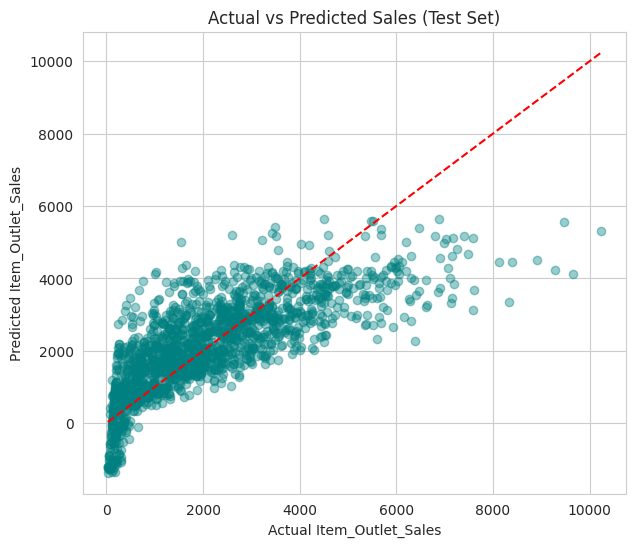

In [16]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Item_Outlet_Sales')
plt.ylabel('Predicted Item_Outlet_Sales')
plt.title('Actual vs Predicted Sales (Test Set)')
plt.show()

There's a fair amount of spread around the line, especially for higher sales values, meaning the model is not capturing everything (makes sense, it's a plain linear model and sales data usually has some non-linear patterns). But there isn't any extreme/random scatter either, so the model is learning a real relationship, just not a perfect one.

## Step 14: Overfitting Analysis (comparing Train vs Test)

This is the actual point of the lab. My results:

| Metric | Train | Test |
|---|---|---|
| MAE | 847.29 | 791.60 |
| MSE | 1,304,353.69 | 1,142,642.16 |
| RMSE | 1142.08 | 1068.94 |
| R2 | 0.5590 | 0.5796 |

Normally when overfitting happens, training performance is noticeably **better** than testing performance (low train error, high test error / high train R2, low test R2), because the model has basically memorized the training data instead of learning a general pattern.

But here it's actually the opposite (a small amount) - test R2 (0.5796) is a bit **higher** than train R2 (0.5590), and all the test errors (MAE, MSE, RMSE) are slightly **lower** than train errors. The gap either way is small (~0.02 in R2), not something like 0.9 train vs 0.4 test which is the classic overfitting signature.

This can happen with a single train-test split just by chance - the random 20% that ended up in the test set may have been a slightly "easier"/less noisy set of rows to predict. It doesn't mean the model is doing something wrong, it actually means the opposite - there's no sign of the model performing worse on unseen data, which is what we're actually checking for.

## Step 15: Is the Model Generalized or Overfitted?

Based on the above comparison - **the model is generalized, not overfitted.**

Reasoning:
- Train and test R2 are close to each other (0.559 vs 0.580), not a big gap.
- Test error is not higher than train error (if anything it's marginally lower), so the model is not failing on unseen data.
- R2 of ~0.56-0.58 isn't very high in absolute terms, but that's a sign of **underfitting/model simplicity** at most (a plain linear model can only capture linear relationships, and this data probably has non-linear patterns like the scatter plot in Step 13 showed), not overfitting. Overfitting and low R2 on train itself basically don't happen together - an overfitted model would have a very high train R2.

To be more confident about this rather than trusting just one random split, I also ran 5-fold cross-validation on the whole dataset:

In [17]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("R2 scores for each fold:", np.round(cv_scores, 4))
print("Mean CV R2:", round(cv_scores.mean(), 4))
print("Std Dev   :", round(cv_scores.std(), 4))

R2 scores for each fold: [0.5693 0.5519 0.5471 0.5627 0.5627]
Mean CV R2: 0.5587
Std Dev   : 0.0081


The R2 across all 5 folds stays in a tight range (roughly 0.547 to 0.569) with a mean of about 0.559, and a very small standard deviation (~0.008). This matches the train/test R2 values from before, and the fact that it's consistent across different folds (different subsets of data) confirms that the model isn't just getting lucky/unlucky on one particular split - it genuinely performs similarly on any unseen portion of the data. This backs up the conclusion that the model **generalizes well** and is not overfitted.

## Step 16: Ways to Reduce/Avoid Overfitting

Even though this particular model isn't overfitting, these are the standard methods (and how they'd actually apply here):

1. **Feature Selection** - Not all 40+ one-hot encoded columns from `Item_Type` (16 categories) are equally useful. Some item types have very few rows, and keeping every single one adds noise/unnecessary complexity. Could check feature importance (coefficients) and drop the ones with negligible effect on sales.

2. **Cross-Validation** - Already used this in Step 15 above. Instead of relying on just one train-test split (which can be lucky/unlucky), k-fold CV trains and tests on multiple different splits and averages the result, giving a much more reliable estimate of how the model will actually perform.

3. **Removing Irrelevant Variables** - Already did this in Step 6 by dropping `Item_Identifier` and `Outlet_Identifier`. ID columns are a classic overfitting trap because the model could otherwise try to "memorize" sales per exact ID instead of learning general patterns from actual product/store attributes.

4. Other methods that could help further (didn't implement all of these here since this model wasn't overfitting, but good to note): Regularization (Ridge/Lasso Regression instead of plain Linear Regression), reducing model complexity, and simply collecting more training data if possible.

## Conclusion

Built a Linear Regression model on the BigMart Sales dataset after cleaning inconsistent category labels, imputing missing values in `Item_Weight` and `Outlet_Size`, one-hot encoding the nominal columns, and scaling the numeric ones. The model got an R2 of about 0.56-0.58 on both train and test data, and 5-fold cross-validation confirmed this is consistent. Since train and test performance are close (test isn't worse than train), the model is **generalized and not overfitted** - though the moderate R2 suggests a linear model alone may be underfitting this data slightly, and a non-linear model (like Decision Tree or Random Forest) might capture the patterns better. That would be a good next step to try beyond the scope of this lab.